In [20]:
# Importing the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [21]:
df = pd.read_csv('/kaggle/input/datasets/adnan9299/train-csv/train.csv')

In [22]:
#Understanding The dataset
print(df.shape)  #how many rows and columns 

(614, 13)


In [23]:
df.head()  #first 5 rows 

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [24]:
print(df.dtypes)    # Data types of the each column

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object


In [25]:
print(df.columns.tolist())   # All column names 

['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


Summary: The dataset has ~614 rows and 13 columns Key columns: Loan_ID, Gender, Married, Dependents, Education, Self_Employed, ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History, Property_Area, Loan_Status. Loan_Status is our target variable (Y = approved/no default, N = rejected/default risk)

Exploratory Data Analysis(EDA)

In [26]:
#Basic statistics
df.describe()  # stats for numerics columns 

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [27]:
df.isnull().sum()  # checking for missing values 

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [28]:
# fill missing values 
cols_with_missing = ['Gender','Married','Dependents','Self_Employed','Credit_History','Loan_Amount_Term','LoanAmount']

for col in cols_with_missing:
    df[col].fillna(df[col].mode()[0], inplace = True)

/tmp/ipykernel_55/908525750.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace = True)


Mode is used in data cleaning because it's the only central tendency measure applicable to categorical data, and it fills missing values with the most "typical" or common observation keeping the dataset realistic and distribution preserving.

In [29]:
# confirming that no missing values in the model
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

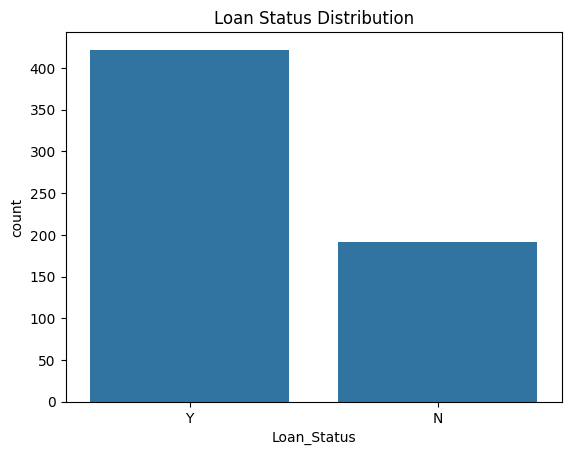

In [30]:
#Visualize the Target Variable
sns.countplot(x='Loan_Status',data=df)
plt.title('Loan Status Distribution')
plt.show()

The dataset is not balanced, The target variable Loan_Status has more than twice as many Y's as N's, with approximately 69% approved (Y) and 31% rejected (N).

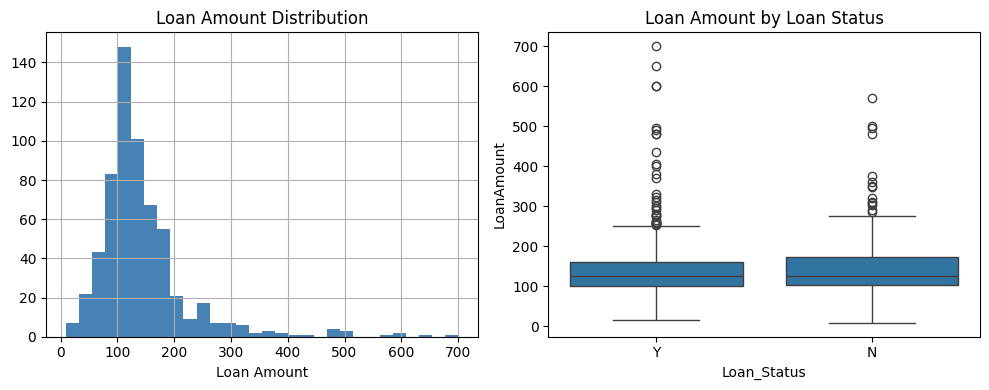

In [31]:
#Visualize loan amount distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
df['LoanAmount'].hist(bins=30, color='steelblue')
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')

plt.subplot(1, 2, 2)
sns.boxplot(x='Loan_Status', y='LoanAmount', data=df)
plt.title('Loan Amount by Loan Status')

plt.tight_layout()
plt.show()


Loan Amount Distribution The majority of applicants request modest loans (under 200), but there are clear outliers going up to 700. This right-skewed distribution is exactly why we used median (not mean) to fill missing values in LoanAmount.

Loan Amount by Loan Status The median and box size are nearly identical for Y and N, Rejected applicants requested slightly higher loan amounts on average This makes intuitive sense — larger loans = higher risk = more rejections

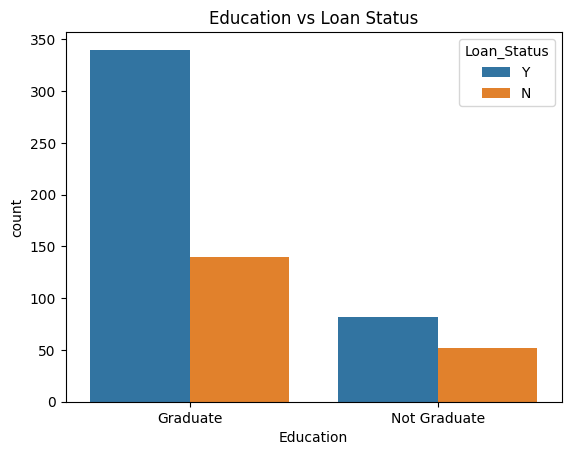

In [32]:
#Visualize Education vs Loan Status
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title('Education vs Loan Status')
plt.show()

Summary Let's calculate the approval rate for each group:

Group	Y	N	Total	Approval %
Graduate	340	140	480	~71%
Not Graduate	83	52	135	~61%
Graduates get approved ~10% more often than non-graduates, education does make a difference.

Banks consider education level as a proxy for employment stability and earning potential. Graduates are seen as lower risk because they can have more stable, higher-paying jobs: making them more likely to repay loans.

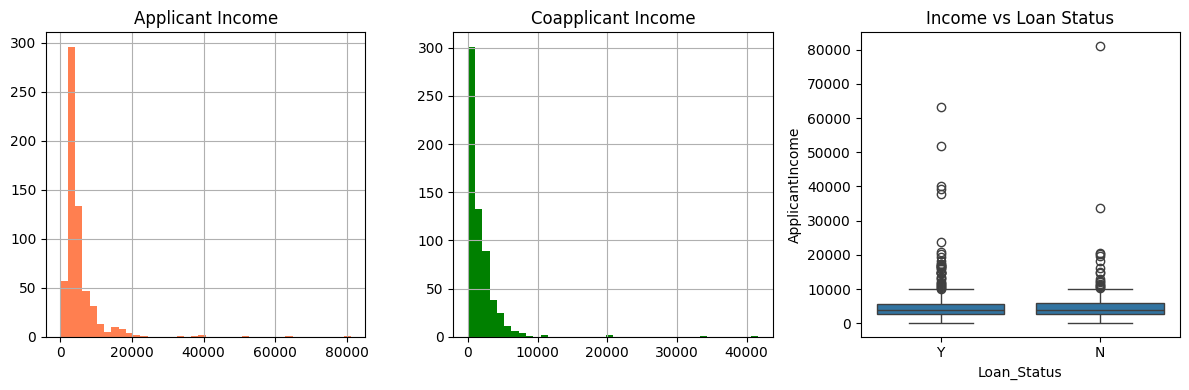

In [33]:
#Visualize Income Distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df['ApplicantIncome'].hist(bins=40, color='coral')
plt.title('Applicant Income')

plt.subplot(1, 3, 2)
df['CoapplicantIncome'].hist(bins=40, color='green')
plt.title('Coapplicant Income')

plt.subplot(1, 3, 3)
sns.boxplot(x='Loan_Status', y='ApplicantIncome', data=df)
plt.title('Income vs Loan Status')

plt.tight_layout()
plt.show()

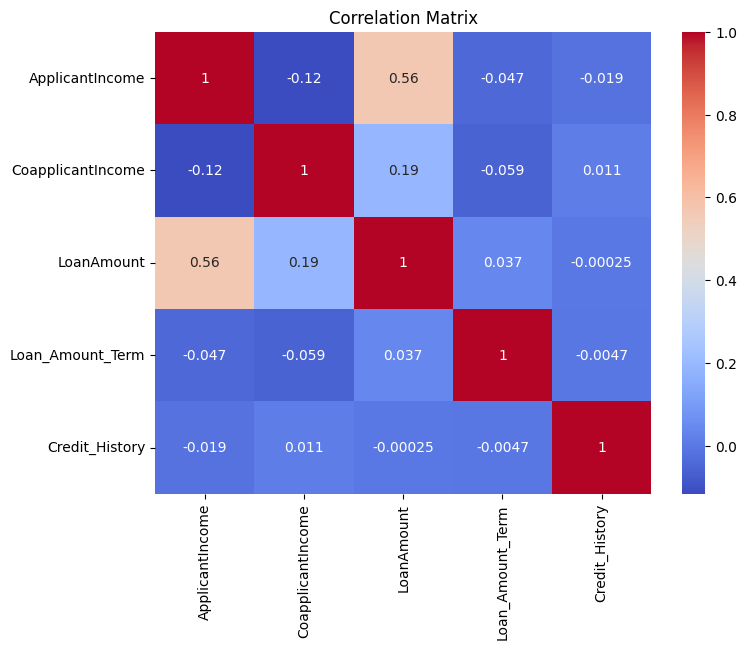

In [34]:
#Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [35]:
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
df['Loan_Status'].value_counts()

Loan_Status
1    422
0    192
Name: count, dtype: int64

In [36]:
#droping non-useful columns
df.drop('Loan_ID', axis=1, inplace=True)

In [37]:

features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                    'Loan_Amount_Term', 'Credit_History']

X = df[features]
y = df['Loan_Status']

print("Feature shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Feature shape: (614, 5)
Target distribution:
 Loan_Status
1    422
0    192
Name: count, dtype: int64


In [38]:
#Splitting the data for training & Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # For reproducibility
    stratify=y           # the dataset is slightly imbalanced (more Y than N), stratify ensures both splits have the same class ratio.
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (491, 5)
Testing size: (123, 5)


Train Classification Models 

In [39]:
#A-Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

In [40]:
#B-Decision Tree
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)

Evaluate the Models

In [41]:
#a. Accuracy Score
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_preds))
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_preds))

Logistic Regression Accuracy: 0.8617886178861789
Decision Tree Accuracy: 0.8048780487804879


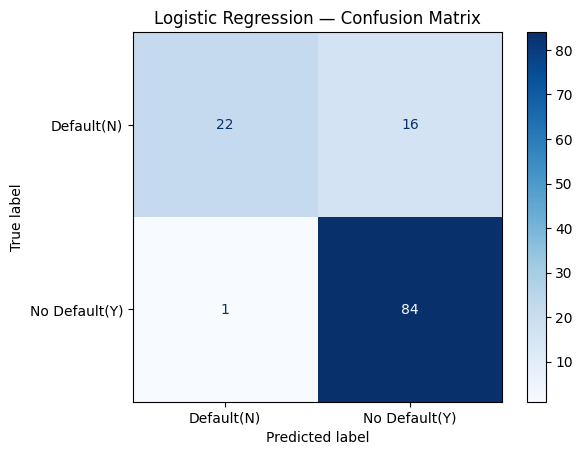

In [42]:
#b. Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['Default(N)', 'No Default(Y)'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.show()

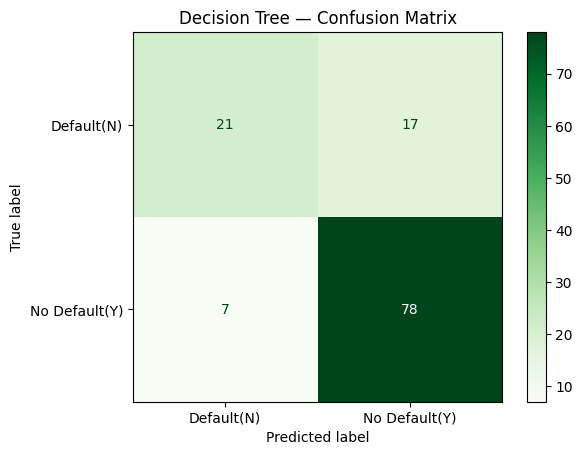

In [43]:
#c. Confusion Matrix for Decision Tree
cm_dt = confusion_matrix(y_test, dt_preds)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['Default(N)', 'No Default(Y)'])
disp2.plot(cmap='Greens')
plt.title('Decision Tree — Confusion Matrix')
plt.show()

In [44]:
print(classification_report(y_test, lr_preds))

              precision    recall  f1-score   support

           0       0.96      0.58      0.72        38
           1       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



In [45]:
print(classification_report(y_test, dt_preds))

              precision    recall  f1-score   support

           0       0.75      0.55      0.64        38
           1       0.82      0.92      0.87        85

    accuracy                           0.80       123
   macro avg       0.79      0.74      0.75       123
weighted avg       0.80      0.80      0.80       123

